=== TESTING RESNET18 ===


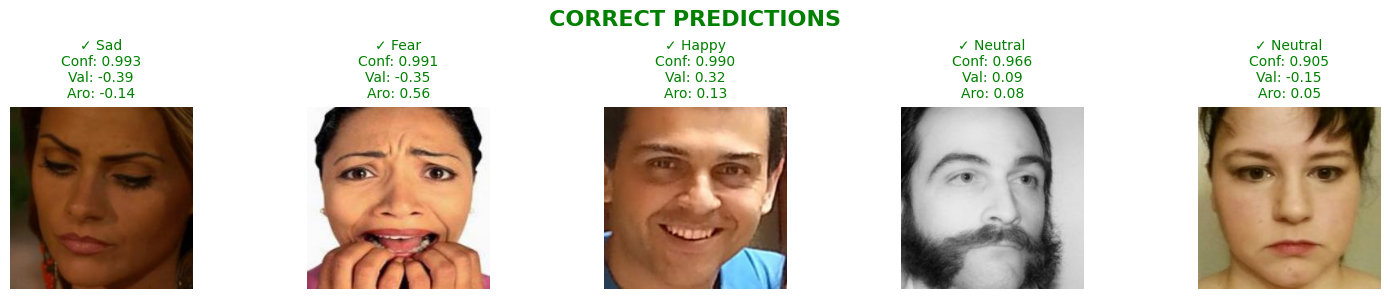

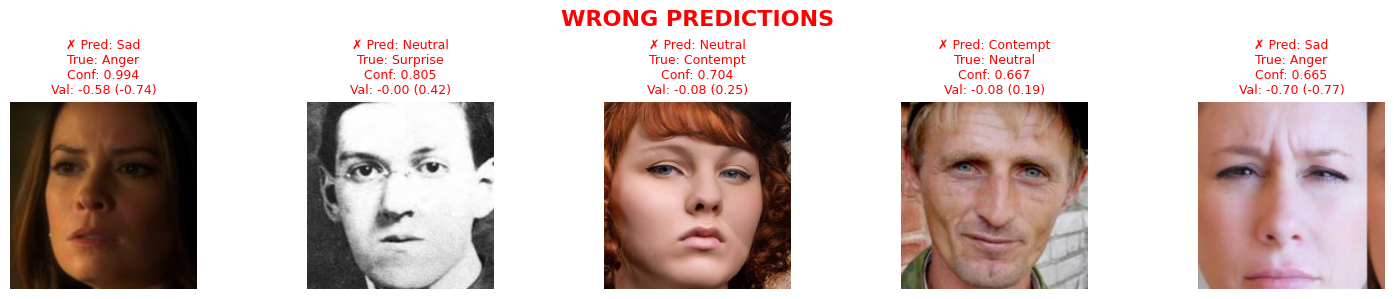


=== SUMMARY ===
Total samples tested: 20
Correct predictions: 12
Wrong predictions: 8
Accuracy: 0.600 (60.0%)

=== SAMPLE DETAILS ===
✓ Sample 1: True=Fear, Pred=Fear, Conf=0.991
✗ Sample 2: True=Surprise, Pred=Neutral, Conf=0.805
✗ Sample 3: True=Contempt, Pred=Neutral, Conf=0.704
✓ Sample 4: True=Happy, Pred=Happy, Conf=0.990
✓ Sample 5: True=Fear, Pred=Fear, Conf=0.749


=== TESTING VGG16 ===


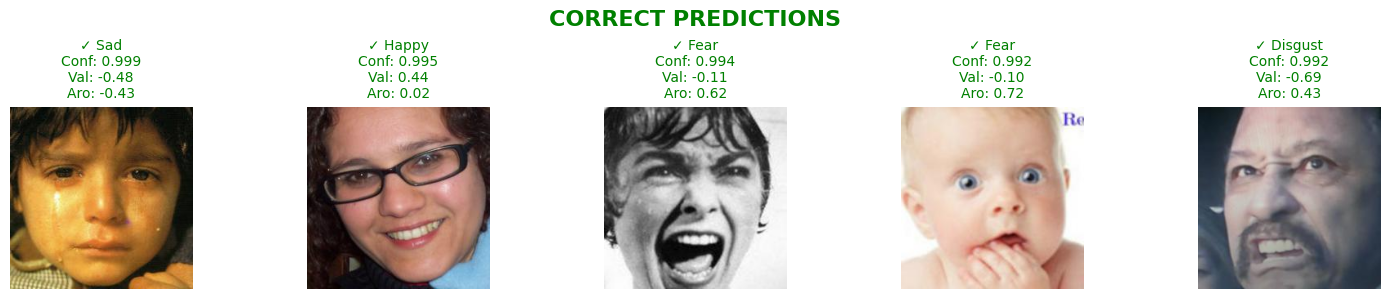

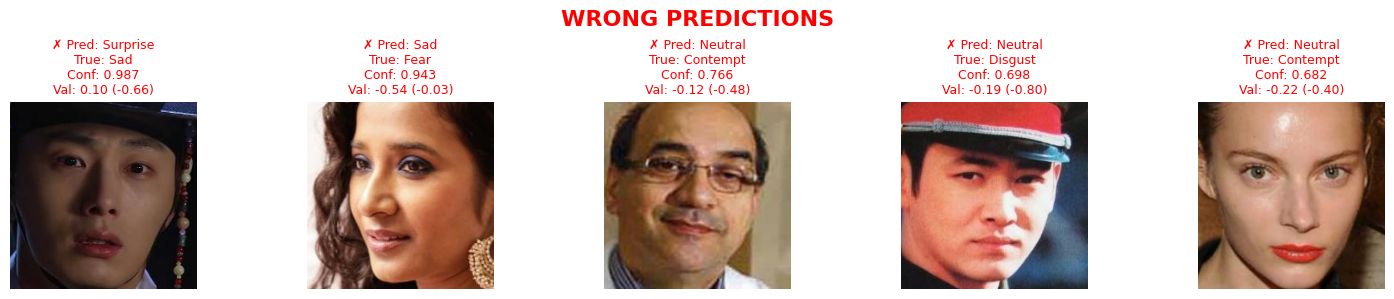


=== SUMMARY ===
Total samples tested: 20
Correct predictions: 14
Wrong predictions: 6
Accuracy: 0.700 (70.0%)

=== SAMPLE DETAILS ===
✗ Sample 1: True=Contempt, Pred=Neutral, Conf=0.682
✓ Sample 2: True=Sad, Pred=Sad, Conf=0.959
✓ Sample 3: True=Fear, Pred=Fear, Conf=0.992
✓ Sample 4: True=Contempt, Pred=Contempt, Conf=0.815
✓ Sample 5: True=Sad, Pred=Sad, Conf=0.999


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms, models
import random

# Emotion labels
EMOTIONS = {0: "Neutral", 1: "Happy", 2: "Sad", 3: "Surprise", 
           4: "Fear", 5: "Disgust", 6: "Anger", 7: "Contempt"}

# ResNet18 model
class ResNetMultiHead(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        base = models.resnet18(pretrained=True)
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        feat_dim = 512
        self.expr_head = nn.Linear(feat_dim, num_classes)
        self.val_head = nn.Linear(feat_dim, 1)
        self.aro_head = nn.Linear(feat_dim, 1)

    def forward(self, x):
        feat = self.backbone(x)
        feat = torch.flatten(feat, 1)
        return {
            "logits": self.expr_head(feat),
            "valence": self.val_head(feat).squeeze(1),
            "arousal": self.aro_head(feat).squeeze(1)
        }

# VGG model (based on your actual architecture)
class VGGMultiHead(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        # Your VGG uses 'backbone' instead of 'features'
        vgg = models.vgg16(pretrained=True)
        self.backbone = vgg.features  # This matches your saved model
        self.avgpool = vgg.avgpool
        
        # Your model uses 'fc' layers with 4096 output (not 1024)
        self.fc = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),  # Your model has 4096 here, not 1024
            nn.ReLU(True),
            nn.Dropout(),
        )
        
        # Task-specific heads expect 4096 input (not 1024)
        self.expr_head = nn.Linear(4096, num_classes)
        self.val_head = nn.Linear(4096, 1)
        self.aro_head = nn.Linear(4096, 1)

    def forward(self, x):
        x = self.backbone(x)  # Use backbone instead of features
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)  # Use fc instead of classifier
        
        return {
            "logits": self.expr_head(x),
            "valence": self.val_head(x).squeeze(1),
            "arousal": self.aro_head(x).squeeze(1)
        }

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def load_and_test_model(model_path, model_type="resnet", images_dir="images", annotations_dir="annotations", num_samples=10):
    # Load model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Choose model architecture
    if model_type.lower() == "resnet":
        model = ResNetMultiHead()
    elif model_type.lower() == "vgg":
        model = VGGMultiHead()
    else:
        raise ValueError("model_type must be 'resnet' or 'vgg'")
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    # Get all image files
    image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))]
    
    # Randomly sample some images
    sample_files = random.sample(image_files, min(num_samples, len(image_files)))
    
    results = []
    
    with torch.no_grad():
        for img_file in sample_files:
            # Get image ID
            img_id = os.path.splitext(img_file)[0]
            
            # Load and process image
            img_path = os.path.join(images_dir, img_file)
            image = Image.open(img_path).convert("RGB")
            original_image = image.copy()
            
            # Transform image
            input_tensor = transform(image).unsqueeze(0).to(device)
            
            # Load annotations
            true_exp = int(np.load(os.path.join(annotations_dir, f"{img_id}_exp.npy")))
            true_val = float(np.load(os.path.join(annotations_dir, f"{img_id}_val.npy")))
            true_aro = float(np.load(os.path.join(annotations_dir, f"{img_id}_aro.npy")))
            
            # Make prediction
            outputs = model(input_tensor)
            logits = outputs["logits"]
            pred_val = outputs["valence"].item()
            pred_aro = outputs["arousal"].item()
            
            # Get predicted emotion
            probabilities = torch.softmax(logits, dim=1)
            confidence, pred_exp = torch.max(probabilities, dim=1)
            pred_exp = pred_exp.item()
            confidence = confidence.item()
            
            # Store results
            is_correct = (pred_exp == true_exp)
            results.append({
                'id': img_id,
                'image': original_image,
                'true_emotion': true_exp,
                'pred_emotion': pred_exp,
                'confidence': confidence,
                'true_valence': true_val,
                'pred_valence': pred_val,
                'true_arousal': true_aro,
                'pred_arousal': pred_aro,
                'correct': is_correct
            })
    
    return results

def show_predictions(results, num_correct=5, num_wrong=5):
    # Separate correct and wrong predictions
    correct = [r for r in results if r['correct']]
    wrong = [r for r in results if not r['correct']]
    
    # Sort by confidence
    correct.sort(key=lambda x: x['confidence'], reverse=True)
    wrong.sort(key=lambda x: x['confidence'], reverse=True)
    
    # Show correct predictions
    if correct:
        fig, axes = plt.subplots(1, min(num_correct, len(correct)), figsize=(15, 3))
        if min(num_correct, len(correct)) == 1:
            axes = [axes]
        
        fig.suptitle("CORRECT PREDICTIONS", color='green', fontsize=16, fontweight='bold')
        
        for i in range(min(num_correct, len(correct))):
            sample = correct[i]
            ax = axes[i]
            ax.imshow(sample['image'])
            ax.axis('off')
            
            title = f"✓ {EMOTIONS[sample['pred_emotion']]}\n"
            title += f"Conf: {sample['confidence']:.3f}\n"
            title += f"Val: {sample['pred_valence']:.2f}\n"
            title += f"Aro: {sample['pred_arousal']:.2f}"
            ax.set_title(title, fontsize=10, color='green')
        
        plt.tight_layout()
        plt.show()
    
    # Show wrong predictions
    if wrong:
        fig, axes = plt.subplots(1, min(num_wrong, len(wrong)), figsize=(15, 3))
        if min(num_wrong, len(wrong)) == 1:
            axes = [axes]
            
        fig.suptitle("WRONG PREDICTIONS", color='red', fontsize=16, fontweight='bold')
        
        for i in range(min(num_wrong, len(wrong))):
            sample = wrong[i]
            ax = axes[i]
            ax.imshow(sample['image'])
            ax.axis('off')
            
            title = f"✗ Pred: {EMOTIONS[sample['pred_emotion']]}\n"
            title += f"True: {EMOTIONS[sample['true_emotion']]}\n"
            title += f"Conf: {sample['confidence']:.3f}\n"
            title += f"Val: {sample['pred_valence']:.2f} ({sample['true_valence']:.2f})"
            ax.set_title(title, fontsize=9, color='red')
        
        plt.tight_layout()
        plt.show()

def print_summary(results):
    correct_count = sum(1 for r in results if r['correct'])
    total_count = len(results)
    accuracy = correct_count / total_count if total_count > 0 else 0
    
    print(f"\n=== SUMMARY ===")
    print(f"Total samples tested: {total_count}")
    print(f"Correct predictions: {correct_count}")
    print(f"Wrong predictions: {total_count - correct_count}")
    print(f"Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
    
    print(f"\n=== SAMPLE DETAILS ===")
    for i, result in enumerate(results[:5]):  # Show first 5 samples
        status = "✓" if result['correct'] else "✗"
        print(f"{status} Sample {i+1}: True={EMOTIONS[result['true_emotion']]}, "
              f"Pred={EMOTIONS[result['pred_emotion']]}, Conf={result['confidence']:.3f}")

# Main execution
if __name__ == "__main__":
    # Test ResNet18
    resnet_model_path = "best_resnet18.pt"
    if os.path.exists(resnet_model_path):
        print("=== TESTING RESNET18 ===")
        resnet_results = load_and_test_model(resnet_model_path, model_type="resnet", num_samples=20)
        show_predictions(resnet_results, num_correct=5, num_wrong=5)
        print_summary(resnet_results)
    else:
        print(f"ResNet18 model file '{resnet_model_path}' not found!")
    
    print("\n" + "="*50 + "\n")
    
    # Test VGG16
    vgg_model_path = "best_vgg.pt"  # Change to your VGG16 model path
    if os.path.exists(vgg_model_path):
        print("=== TESTING VGG16 ===")
        vgg_results = load_and_test_model(vgg_model_path, model_type="vgg", num_samples=20)
        show_predictions(vgg_results, num_correct=5, num_wrong=5)
        print_summary(vgg_results)
    else:
        print(f"VGG16 model file '{vgg_model_path}' not found!")
        print("If you have a VGG16 model, update the 'vgg_model_path' variable with the correct filename.")